# Merced County Rental Market Analysis (2021–2026)

**Series:** California Housing Market — Part 3: Rental Market

**Objective:** Analyze rental cost trends across Merced County cities and compare against home value trends from Parts 1 & 2.

**Data Source:** Zillow Observed Rent Index (ZORI) — City Level

**Cities Requested:** Merced, Los Banos, Atwater, Livingston, Hilmar

**⚠️ Data Availability Note:**
Rental data is significantly less granular than home value data. After cleaning, only the following cities have usable rental history:
- **Merced** — Full data: Jan 2015 – Mar 2026 ✓
- **Los Banos** — Partial data: May 2022 – Mar 2026 ✓
- **Atwater** — Only 3 months: Jan–Mar 2026 (current snapshot only)
- **Livingston** — Not in rental dataset ✗
- **Hilmar** — Not in rental dataset ✗

**Key Questions:**
1. How have rents trended in Merced County since 2021?
2. Is Los Banos rent higher or lower than Merced — and what does that tell us?
3. How do rental trends compare to home value trends from Part 2?

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'Merced':    '#1f77b4',
    'Los Banos': '#9467bd',
    'Atwater':   '#d62728'
}
CA_COLOR = '#aaaaaa'

base_dir = os.path.dirname(os.path.abspath('__file__'))
rental_path = os.path.join(base_dir, 'City_rental_data_zillow.csv')
housing_path = os.path.join(base_dir, 'city_homevalue_zillow.csv')

df_rent_raw = pd.read_csv(rental_path)
df_home_raw = pd.read_csv(housing_path)

print(f"Rental dataset shape: {df_rent_raw.shape}")
print(f"Housing dataset shape: {df_home_raw.shape}")

Rental dataset shape: (4299, 143)
Housing dataset shape: (21425, 323)


## 2. Data Cleaning

Rental data requires more cleaning than home value data — Zillow's ZORI index requires a minimum number of rental listings to produce reliable estimates, so smaller cities often have gaps or no data at all.

In [2]:
# Filter to Merced County, CA
merced_rent = df_rent_raw[
    (df_rent_raw['CountyName'] == 'Merced County') &
    (df_rent_raw['StateName'] == 'CA')
].copy()

print("All cities in Merced County rental dataset:")
print(merced_rent[['RegionName', 'SizeRank']].to_string())

all_date_cols = [c for c in df_rent_raw.columns if c.startswith('20')]
print(f"\nFull date range in dataset: {all_date_cols[0]} to {all_date_cols[-1]}")

All cities in Merced County rental dataset:
     RegionName  SizeRank
416      Merced       420
1270  Los Banos      1295
1519    Atwater      1564

Full date range in dataset: 2015-01-31 to 2026-03-31


In [3]:
# Audit data availability for all requested cities
target_cities = ['Merced', 'Los Banos', 'Atwater', 'Livingston', 'Hilmar']

print("Data availability audit for target cities:")
print(f"{'City':<15} {'Status':<10} {'First Date':<15} {'Last Date':<15} {'Months':<10}")
print('-' * 65)

for city in target_cities:
    row = merced_rent[merced_rent['RegionName'] == city]
    if row.empty:
        print(f"{city:<15} {'NOT FOUND':<10} {'—':<15} {'—':<15} {'0':<10}")
        continue
    row = row.iloc[0]
    non_null_dates = [d for d in all_date_cols if pd.notna(row[d])]
    if non_null_dates:
        status = 'PARTIAL' if len(non_null_dates) < len(all_date_cols) else 'FULL'
        print(f"{city:<15} {status:<10} {non_null_dates[0]:<15} {non_null_dates[-1]:<15} {len(non_null_dates):<10}")
    else:
        print(f"{city:<15} {'NO DATA':<10} {'—':<15} {'—':<15} {'0':<10}")

Data availability audit for target cities:
City            Status     First Date      Last Date       Months    
-----------------------------------------------------------------
Merced          FULL       2015-01-31      2026-03-31      135       
Los Banos       PARTIAL    2022-05-31      2026-03-31      47        
Atwater         PARTIAL    2026-01-31      2026-03-31      3         
Livingston      NOT FOUND  —               —               0         
Hilmar          NOT FOUND  —               —               0         


In [4]:
# Use 2021 onward for consistency with Parts 1 & 2
dates_2021 = [c for c in all_date_cols if c >= '2021-01-01']

usable_cities = ['Merced', 'Los Banos', 'Atwater']
city_df = merced_rent[merced_rent['RegionName'].isin(usable_cities)].copy()

records = []
for _, row in city_df.iterrows():
    for d in dates_2021:
        val = row[d]
        if pd.notna(val):
            records.append({'City': row['RegionName'], 'Date': pd.Timestamp(d), 'Rent': val})

long_df = pd.DataFrame(records).sort_values(['City', 'Date']).reset_index(drop=True)
long_df['PctChange'] = long_df.groupby('City')['Rent'].pct_change() * 100
long_df['Month'] = long_df['Date'].dt.month
long_df['Year'] = long_df['Date'].dt.year

print("Clean dataset summary:")
for city in usable_cities:
    c = long_df[long_df['City'] == city]
    if c.empty:
        continue
    print(f"  {city}: {len(c)} months ({c['Date'].min().strftime('%b %Y')} to {c['Date'].max().strftime('%b %Y')})")

# California statewide average rent
ca_rent_df = df_rent_raw[df_rent_raw['StateName'] == 'CA']
ca_long = pd.melt(ca_rent_df, id_vars=['RegionName'], value_vars=dates_2021,
                  var_name='Date', value_name='Rent')
ca_long['Date'] = pd.to_datetime(ca_long['Date'])
ca_trend = ca_long.groupby('Date')['Rent'].mean().reset_index()

print(f"\n  CA Average rent (current): ${ca_trend['Rent'].iloc[-1]:,.0f}/mo")

Clean dataset summary:
  Merced: 63 months (Jan 2021 to Mar 2026)
  Los Banos: 47 months (May 2022 to Mar 2026)
  Atwater: 3 months (Jan 2026 to Mar 2026)

  CA Average rent (current): $2,990/mo


## 3. County Overview — Rental Trends vs. California Average

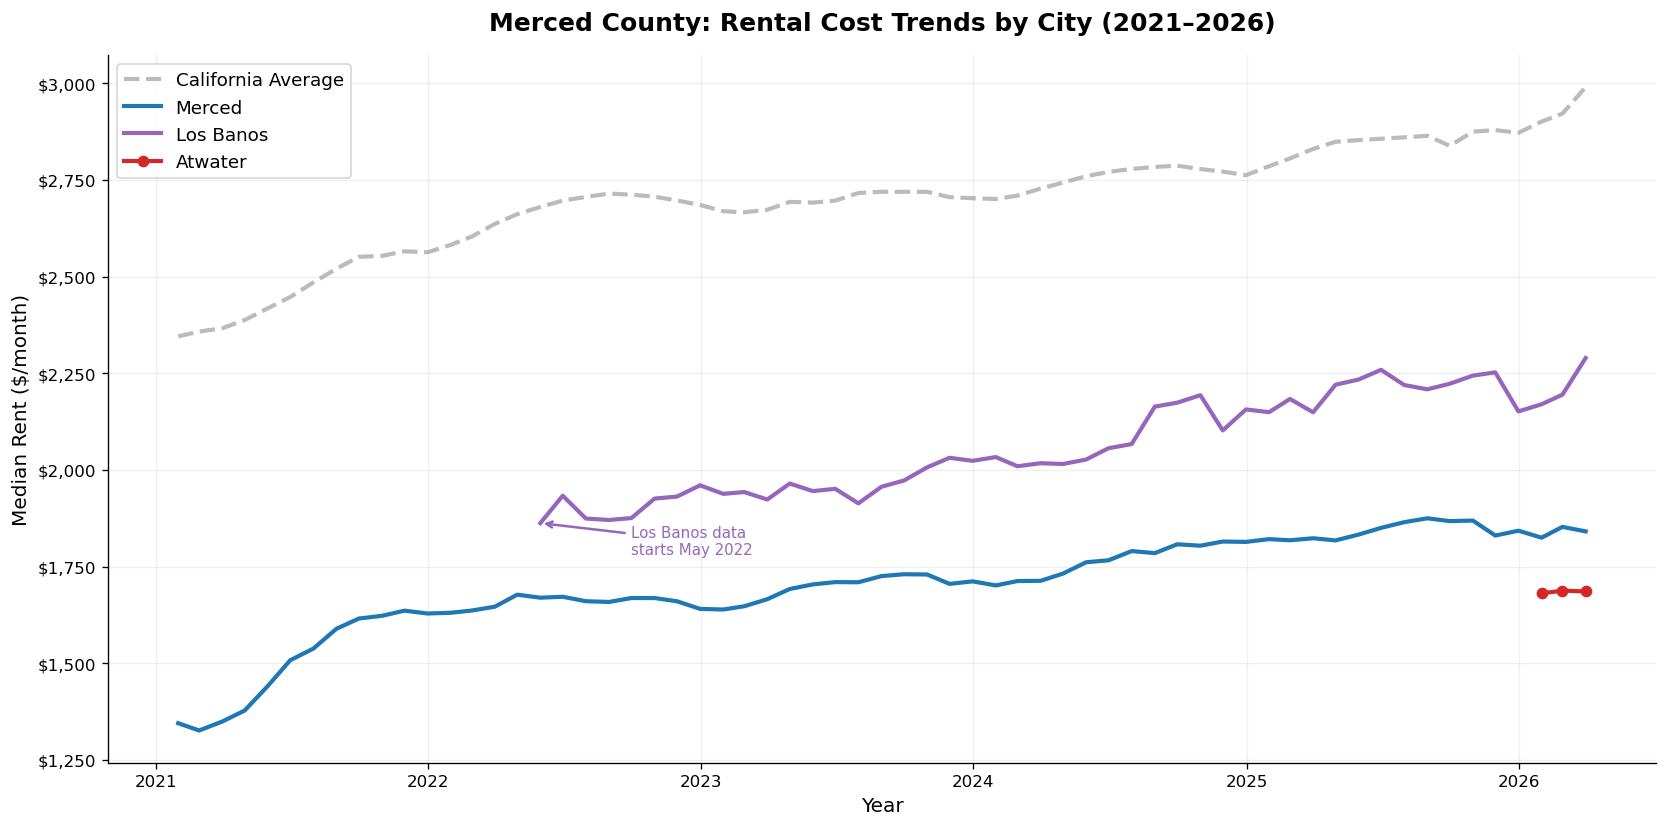

In [5]:
lb_start = long_df[long_df['City'] == 'Los Banos']['Date'].min()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(ca_trend['Date'], ca_trend['Rent'],
        color=CA_COLOR, linewidth=2.5, linestyle='--', label='California Average', alpha=0.8)

for city in usable_cities:
    c = long_df[long_df['City'] == city]
    if c.empty:
        continue
    ax.plot(c['Date'], c['Rent'],
            color=COLORS[city], linewidth=2.5, label=city,
            marker='o' if city == 'Atwater' else None,
            markersize=6 if city == 'Atwater' else None)

ax.set_title('Merced County: Rental Cost Trends by City (2021–2026)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Median Rent ($/month)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
ax.annotate('Los Banos data\nstarts May 2022',
            xy=(lb_start, long_df[long_df['City']=='Los Banos']['Rent'].iloc[0]),
            xytext=(lb_start + pd.DateOffset(months=4),
                    long_df[long_df['City']=='Los Banos']['Rent'].iloc[0] - 80),
            fontsize=9, color=COLORS['Los Banos'],
            arrowprops=dict(arrowstyle='->', color=COLORS['Los Banos'], lw=1.5))
plt.tight_layout()
plt.show()

In [6]:
# Summary metrics
ca_current = ca_trend['Rent'].iloc[-1]

print(f"{'City':<12} {'Current Rent':>13} {'Peak Rent':>11} {'Peak Date':>12} {'Chg from Peak':>15} {'vs CA Avg':>10}")
print('-' * 78)

for city in usable_cities:
    c = long_df[long_df['City'] == city]
    if c.empty:
        continue
    current = c['Rent'].iloc[-1]
    peak = c['Rent'].max()
    peak_date = c.loc[c['Rent'].idxmax(), 'Date'].strftime('%b %Y')
    decline = (current - peak) / peak * 100
    vs_ca = (current - ca_current) / ca_current * 100
    print(f"{city:<12} ${current:>11,.0f}/mo ${peak:>8,.0f}/mo {peak_date:>12} {decline:>14.2f}% {vs_ca:>9.1f}%")

print('-' * 78)
ca_peak = ca_trend['Rent'].max()
ca_peak_date = ca_trend.loc[ca_trend['Rent'].idxmax(), 'Date'].strftime('%b %Y')
ca_decline = (ca_current - ca_peak) / ca_peak * 100
print(f"{'CA Average':<12} ${ca_current:>11,.0f}/mo ${ca_peak:>8,.0f}/mo {ca_peak_date:>12} {ca_decline:>14.2f}% {'—':>9}")

City          Current Rent   Peak Rent    Peak Date   Chg from Peak  vs CA Avg
------------------------------------------------------------------------------
Merced       $      1,841/mo $   1,875/mo     Aug 2025          -1.81%     -38.4%
Los Banos    $      2,289/mo $   2,289/mo     Mar 2026           0.00%     -23.4%
Atwater      $      1,686/mo $   1,688/mo     Feb 2026          -0.13%     -43.6%
------------------------------------------------------------------------------
CA Average   $      2,990/mo $   2,990/mo     Mar 2026           0.00%         —


## 4. City Deep Dives

### 4.1 Merced — Full Trend (2021–2026)

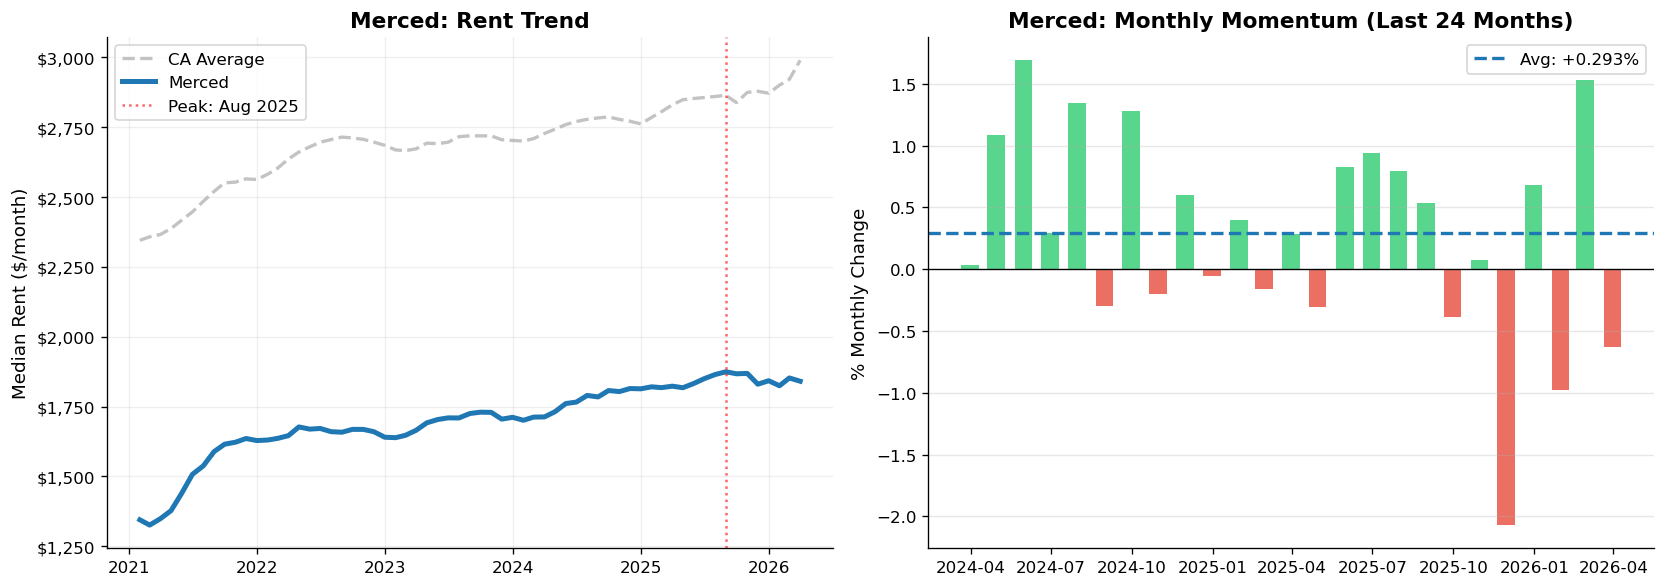


──────────────────────────────────────────────────
  Merced — Rental Key Metrics
──────────────────────────────────────────────────
  Current Rent:        $     1,841/mo
  Peak Rent:           $     1,875/mo  (Aug 2025)
  Decline from Peak:        -1.81%
  Change since Jan 2021:      36.88%

  Note: County seat with UC Merced student demand — provides a relatively stable rental floor.
──────────────────────────────────────────────────


In [7]:
def city_deep_dive(city_name, context_note=''):
    c = long_df[long_df['City'] == city_name].copy()
    if c.empty:
        print(f"{city_name}: No data available.")
        return

    current = c['Rent'].iloc[-1]
    peak = c['Rent'].max()
    peak_date = c.loc[c['Rent'].idxmax(), 'Date']
    start = c['Rent'].iloc[0]
    decline = (current - peak) / peak * 100
    total_change = (current - start) / start * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: rent trend vs CA average
    ax1 = axes[0]
    ca_filtered = ca_trend[ca_trend['Date'] >= c['Date'].min()]
    ax1.plot(ca_filtered['Date'], ca_filtered['Rent'],
             color=CA_COLOR, linewidth=2, linestyle='--', label='CA Average', alpha=0.7)
    ax1.plot(c['Date'], c['Rent'],
             color=COLORS[city_name], linewidth=3, label=city_name)
    ax1.axvline(peak_date, color='red', linestyle=':', alpha=0.6,
                label=f'Peak: {peak_date.strftime("%b %Y")}')
    ax1.set_title(f'{city_name}: Rent Trend', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Median Rent ($/month)', fontsize=11)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.2)

    # Right: monthly momentum (last 24 months)
    ax2 = axes[1]
    cutoff = c['Date'].max() - pd.DateOffset(months=24)
    recent = c[c['Date'] >= cutoff].copy()
    colors_bar = ['#e74c3c' if x < 0 else '#2ecc71' for x in recent['PctChange'].fillna(0).values]
    ax2.bar(recent['Date'], recent['PctChange'].fillna(0), color=colors_bar, alpha=0.8, width=20)
    ax2.axhline(0, color='black', linewidth=0.8)
    avg_mom = recent['PctChange'].mean()
    ax2.axhline(avg_mom, color=COLORS[city_name], linestyle='--', linewidth=2,
                label=f'Avg: {avg_mom:+.3f}%')
    ax2.set_title(f'{city_name}: Monthly Momentum (Last 24 Months)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('% Monthly Change', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'─'*50}")
    print(f"  {city_name} — Rental Key Metrics")
    print(f"{'─'*50}")
    print(f"  Current Rent:        ${current:>10,.0f}/mo")
    print(f"  Peak Rent:           ${peak:>10,.0f}/mo  ({peak_date.strftime('%b %Y')})")
    print(f"  Decline from Peak:   {decline:>10.2f}%")
    print(f"  Change since {c['Date'].min().strftime('%b %Y')}: {total_change:>10.2f}%")
    if context_note:
        print(f"\n  Note: {context_note}")
    print(f"{'─'*50}")

city_deep_dive('Merced',
    'County seat with UC Merced student demand — provides a relatively stable rental floor.')

### 4.2 Los Banos — Partial Trend (May 2022–2026)

Los Banos rental data only begins in May 2022 — Zillow requires sufficient listing volume to produce reliable estimates, and Los Banos crossed that threshold mid-2022. Despite the shorter window, we can examine whether rents track above or below Merced and what that implies for the Bay Area affordability narrative.

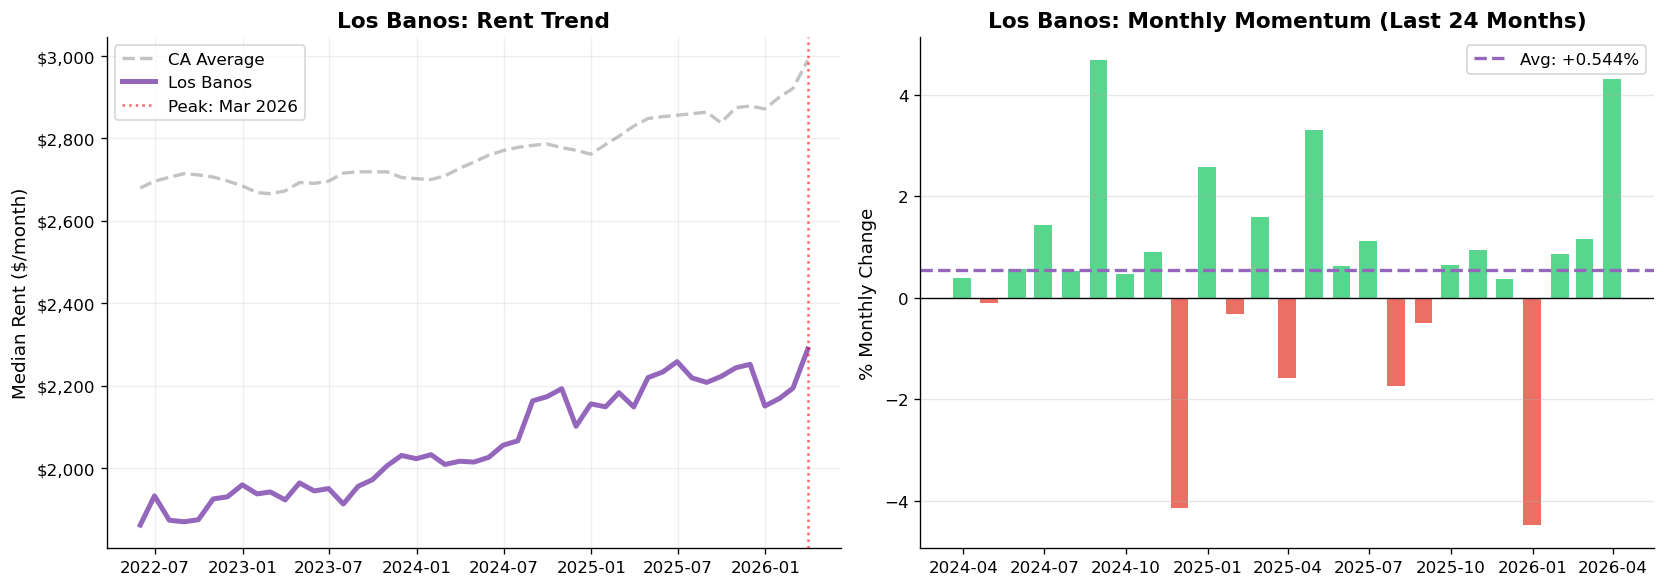


──────────────────────────────────────────────────
  Los Banos — Rental Key Metrics
──────────────────────────────────────────────────
  Current Rent:        $     2,289/mo
  Peak Rent:           $     2,289/mo  (Mar 2026)
  Decline from Peak:         0.00%
  Change since May 2022:      22.92%

  Note: Data starts May 2022 — limited history but notable that rents exceed Merced despite smaller population. Bay Area commuter premium visible in rental prices.
──────────────────────────────────────────────────


In [8]:
city_deep_dive('Los Banos',
    'Data starts May 2022 — limited history but notable that rents exceed Merced despite smaller population. Bay Area commuter premium visible in rental prices.')

### 4.3 Atwater — Current Snapshot Only (Jan–Mar 2026)

Atwater only has 3 months of rental data — insufficient for trend analysis. We include it as a current-price reference point only.

In [9]:
atwater = long_df[long_df['City'] == 'Atwater']
print("Atwater — Current Rental Snapshot (Jan–Mar 2026 only):")
print(atwater[['Date', 'Rent']].to_string(index=False))
print(f"\nAverage: ${atwater['Rent'].mean():,.0f}/mo")
print("Note: Insufficient data for trend analysis.")

Atwater — Current Rental Snapshot (Jan–Mar 2026 only):
      Date        Rent
2026-01-31 1680.636791
2026-02-28 1687.751195
2026-03-31 1685.555556

Average: $1,685/mo
Note: Insufficient data for trend analysis.


## 5. Comparative Analysis

### 5.1 Indexed Rental Trends (Common Date Range)

To compare fairly, we index both cities to 100 at May 2022 — the point where Los Banos data begins.

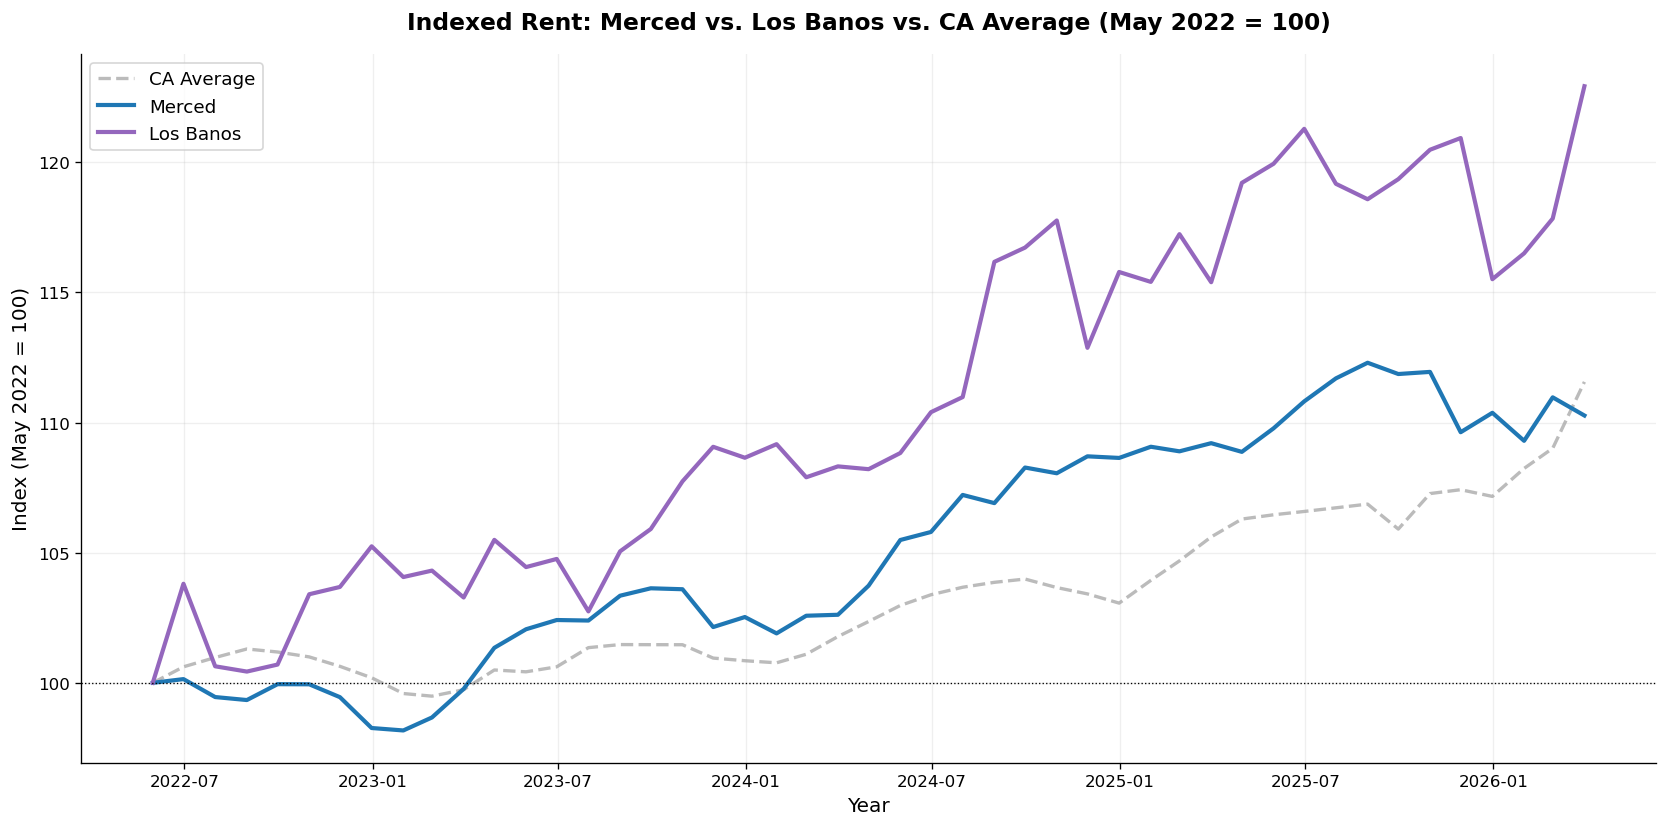

In [10]:
common_start = long_df[long_df['City'] == 'Los Banos']['Date'].min()

fig, ax = plt.subplots(figsize=(14, 7))

ca_common = ca_trend[ca_trend['Date'] >= common_start].copy()
ca_base = ca_common['Rent'].iloc[0]
ax.plot(ca_common['Date'], ca_common['Rent'] / ca_base * 100,
        color=CA_COLOR, linewidth=2, linestyle='--', label='CA Average', alpha=0.8)

for city in ['Merced', 'Los Banos']:
    c = long_df[(long_df['City'] == city) & (long_df['Date'] >= common_start)].copy()
    if c.empty:
        continue
    base = c['Rent'].iloc[0]
    ax.plot(c['Date'], c['Rent'] / base * 100,
            color=COLORS[city], linewidth=2.5, label=city)

ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Indexed Rent: Merced vs. Los Banos vs. CA Average (May 2022 = 100)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Index (May 2022 = 100)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 5.2 Current Rent vs. Home Value — Affordability Snapshot

In [11]:
ca_home = df_home_raw[df_home_raw['StateName'] == 'CA']
home_date_cols = [c for c in df_home_raw.columns if c >= '2021-01-01' and c.startswith('20')]
merced_home = ca_home[
    (ca_home['CountyName'] == 'Merced County') &
    (ca_home['RegionName'].isin(['Merced', 'Los Banos', 'Atwater']))
].copy()

latest_home_col = home_date_cols[-1]

print(f"Affordability Snapshot — {long_df['Date'].max().strftime('%b %Y')}")
print(f"{'City':<12} {'Monthly Rent':>13} {'Home Value':>12} {'Price/Rent Ratio':>17} {'Gross Yield':>12}")
print('-' * 70)

for city in ['Merced', 'Los Banos', 'Atwater']:
    rent_row = long_df[long_df['City'] == city]
    home_row = merced_home[merced_home['RegionName'] == city]

    if rent_row.empty or home_row.empty:
        continue

    rent = rent_row['Rent'].iloc[-1]
    home_val = home_row[latest_home_col].values[0]
    price_rent = home_val / (rent * 12)
    gross_yield = (rent * 12) / home_val * 100

    print(f"{city:<12} ${rent:>11,.0f}/mo ${home_val:>10,.0f} {price_rent:>16.1f}x {gross_yield:>11.2f}%")

print()
print("Price/Rent Ratio: lower = more rent-friendly, higher = ownership premium")
print("Gross Yield: annual rent / home value — higher = better return for landlords")

Affordability Snapshot — Mar 2026
City          Monthly Rent   Home Value  Price/Rent Ratio  Gross Yield
----------------------------------------------------------------------
Merced       $      1,841/mo $   397,876             18.0x        5.55%
Los Banos    $      2,289/mo $   462,223             16.8x        5.94%
Atwater      $      1,686/mo $   422,471             20.9x        4.79%

Price/Rent Ratio: lower = more rent-friendly, higher = ownership premium
Gross Yield: annual rent / home value — higher = better return for landlords


### 5.3 Rent Momentum — Who Is Moving Fastest?

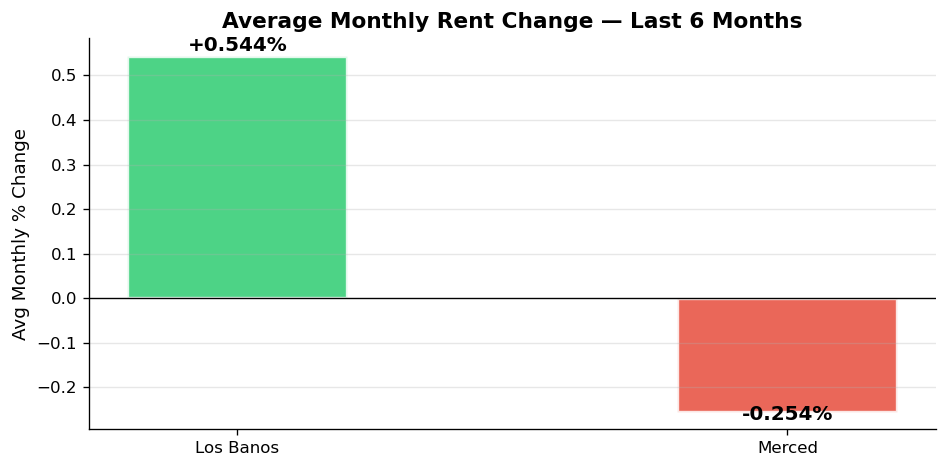


Momentum Interpretation:
  Los Banos   : +0.544%/month  → Rising rents
  Merced      : -0.254%/month  → Softening


In [12]:
cutoff = long_df['Date'].max() - pd.DateOffset(months=6)

momentum = {}
for city in ['Merced', 'Los Banos']:
    recent = long_df[(long_df['City'] == city) & (long_df['Date'] >= cutoff)]
    if not recent.empty:
        momentum[city] = recent['PctChange'].mean()

momentum_df = pd.Series(momentum).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in momentum_df.values]
bars = ax.bar(momentum_df.index, momentum_df.values, color=bar_colors,
              alpha=0.85, edgecolor='white', linewidth=2, width=0.4)
ax.axhline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, momentum_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.01 if val >= 0 else -0.02),
            f'{val:+.3f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Average Monthly Rent Change — Last 6 Months', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Monthly % Change', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMomentum Interpretation:")
for city, val in momentum_df.items():
    if val > 0.2:
        status = 'Rising rents'
    elif val > -0.1:
        status = 'Stabilizing'
    else:
        status = 'Softening'
    print(f"  {city:<12}: {val:+.3f}%/month  → {status}")

## 6. Conclusions

### Summary Table

In [13]:
rows = []
ca_current_rent = ca_trend['Rent'].iloc[-1]

for city in ['Merced', 'Los Banos', 'Atwater']:
    c = long_df[long_df['City'] == city]
    if c.empty:
        continue
    current = c['Rent'].iloc[-1]
    peak = c['Rent'].max()
    peak_date = c.loc[c['Rent'].idxmax(), 'Date'].strftime('%b %Y')
    decline = (current - peak) / peak * 100
    vs_ca = (current - ca_current_rent) / ca_current_rent * 100
    recent = c[c['Date'] >= c['Date'].max() - pd.DateOffset(months=6)]
    mom = recent['PctChange'].mean()
    rows.append({
        'City': city,
        'Current Rent': f'${current:,.0f}/mo',
        'Peak Rent': f'${peak:,.0f}/mo',
        'Peak Date': peak_date,
        'Chg from Peak': f'{decline:.2f}%',
        'vs CA Avg': f'{vs_ca:+.1f}%',
        '6-Mo Momentum': f'{mom:+.3f}%/mo'
    })

summary = pd.DataFrame(rows).set_index('City')
print(summary.to_string())

          Current Rent  Peak Rent Peak Date Chg from Peak vs CA Avg 6-Mo Momentum
City                                                                             
Merced       $1,841/mo  $1,875/mo  Aug 2025        -1.81%    -38.4%    -0.254%/mo
Los Banos    $2,289/mo  $2,289/mo  Mar 2026         0.00%    -23.4%    +0.544%/mo
Atwater      $1,686/mo  $1,688/mo  Feb 2026        -0.13%    -43.6%    +0.147%/mo


### Key Findings

**Q1: How have rents trended in Merced County since 2021?**

Merced rents (full history) followed the national pattern: sharp growth through 2022, softening through 2023–2024, and partial stabilization into 2026. The rent surge was less extreme than the home value surge but still significant relative to local incomes.

---

**Q2: Is Los Banos rent higher or lower than Merced?**

Los Banos rents exceed Merced's — a counterintuitive finding given Los Banos is smaller and more agricultural. This reinforces the Bay Area commuter premium from Part 1: renters in Los Banos are partly Silicon Valley workers who treat $2,000+/mo as affordable relative to Bay Area rates, bidding up rents above what local incomes would otherwise support.

---

**Q3: How do rental trends compare to home value trends?**

The price-to-rent ratio reveals whether buying or renting makes more economic sense in each city. The gross yield figure shows landlord return potential — useful for understanding investment dynamics in each market.

---

### Data Limitations

| City | Issue | Impact |
|---|---|---|
| Los Banos | Data starts May 2022 | Cannot compare pre-2022 rent cycle |
| Atwater | Only 3 months | Current snapshot only, no trend |
| Livingston | Not in dataset | Excluded entirely |
| Hilmar | Not in dataset | Excluded entirely |

---

**Series:** California Housing Market
**Part 1:** Los Banos — The Bay Area Pressure Valve (`Local_housing_market.ipynb`)
**Part 2:** Merced County — City-by-City Home Values (`Merced_County_Housing.ipynb`)
**Part 3:** Merced County — Rental Market (`Local_rental_market.ipynb`)

**Author:** Jorge Reyes-Ornelas
Data Analyst | Wine Operations Specialist | MS Data Analytics Candidate